In [1]:
# ===============================
# CLUSTERING ANALYSIS ACS WILDA26_01B Team 5
# ===============================

import os
import warnings

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import joblib

In [2]:
# 1. Load the full preprocessed dataset
df = pd.read_csv("full_preprocessed_dataset.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (6741, 10)

First 5 rows:
   SeniorCitizen    tenure  MonthlyCharges  gender_Male  Dependents_Yes  \
0      -0.451189  1.479092        1.115583          1.0             1.0   
1      -0.451189 -1.274783        0.173486          0.0             0.0   
2      -0.451189 -1.069270       -1.071429          1.0             0.0   
3      -0.451189 -1.110373        1.485693          0.0             0.0   
4      -0.451189 -0.945962       -0.869551          0.0             1.0   

   PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber optic  \
0               1.0                0.0                          0.0   
1               1.0                0.0                          0.0   
2               0.0                0.0                          0.0   
3               1.0                0.0                          0.0   
4               0.0                0.0                          0.0   

   Contract_One year  Contract_Two year  
0                0.0                0.0

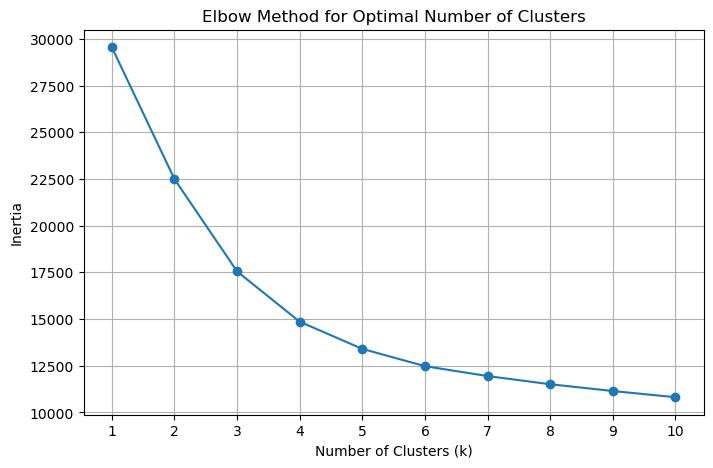

In [3]:
# ===============================
# 2. Determine the optimal number of clusters
#    using the Elbow Method
# ===============================

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [4]:
# 3. Train K-Means model
# Change this after checking the elbow graph
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(df)

print(df["Cluster"].value_counts().sort_index())

Cluster
0    3163
1    2448
2    1130
Name: count, dtype: int64


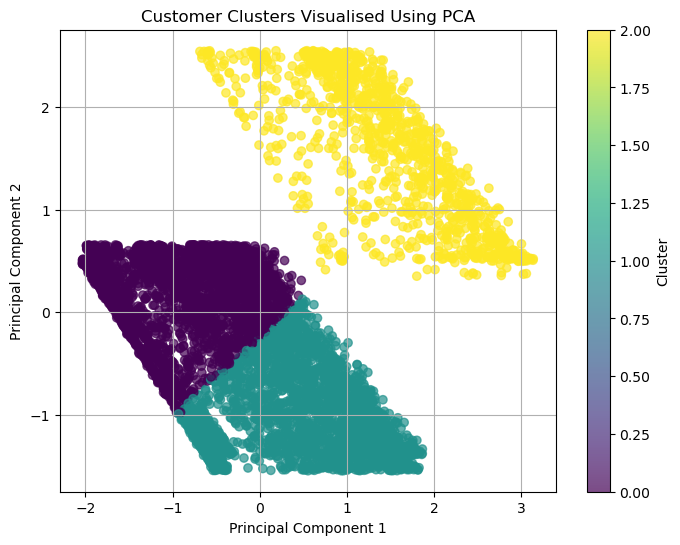

In [5]:
# 4. Visualise clusters using PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df.drop("Cluster", axis=1))

df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], alpha=0.7)
plt.title("Customer Clusters Visualised Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

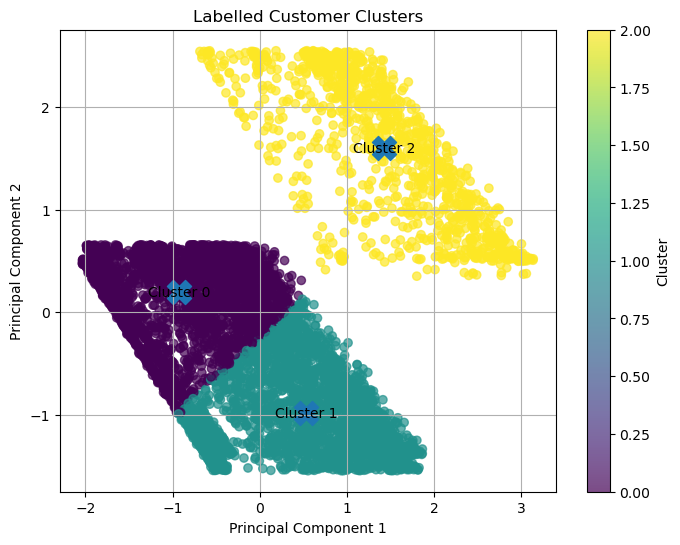

In [6]:
# ===============================
# 5. Label cluster centres on the PCA plot
# ===============================

# Calculate cluster centres in PCA space
centres_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], alpha=0.7)

# Plot cluster centres
plt.scatter(centres_pca[:, 0], centres_pca[:, 1], s=300, marker='X')

# Add labels to cluster centres
for i, (x, y) in enumerate(centres_pca):
    plt.text(x, y, f"Cluster {i}", fontsize=10, ha='center', va='center')

plt.title("Labelled Customer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")
plt.show()

In [7]:
# ===============================
# 6. Interpret clusters
# ===============================

cluster_summary = df.groupby("Cluster").mean()

print("Cluster summary (average feature values):")
print(cluster_summary)

print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())

Cluster summary (average feature values):
         SeniorCitizen    tenure  MonthlyCharges  gender_Male  Dependents_Yes  \
Cluster                                                                         
0            -0.451189 -0.745842       -0.460338     0.496364        0.305722   
1            -0.451189  0.948032        0.377989     0.513072        0.405637   
2             2.216367  0.016857        0.469603     0.501770        0.080531   

         PhoneService_Yes  MultipleLines_Yes  InternetService_Fiber optic  \
Cluster                                                                     
0                0.882390           0.423332                     0.441037   
1                0.919118           0.421569                     0.447712   
2                0.908850           0.420354                     0.419469   

         Contract_One year  Contract_Two year      PCA1      PCA2  
Cluster                                                            
0                 0.217199    

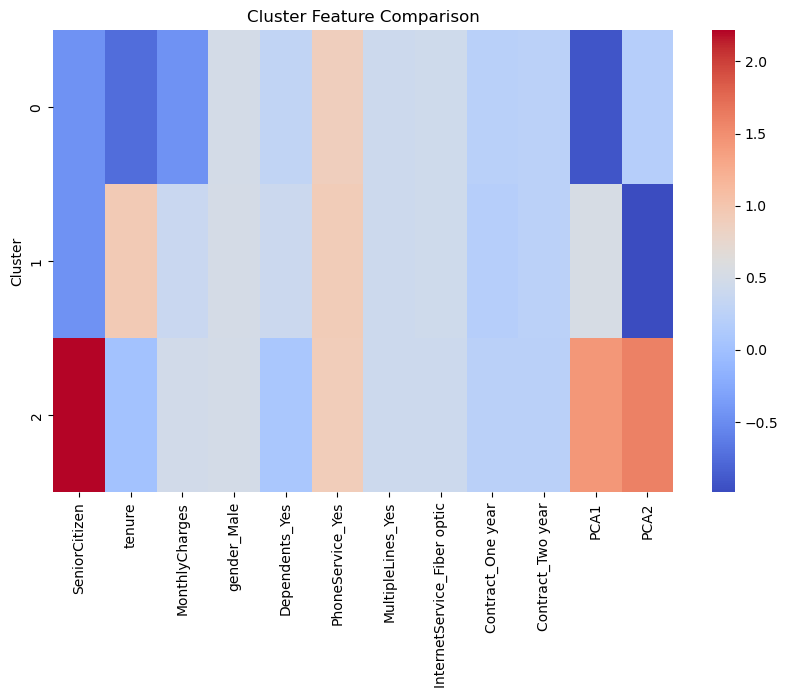

In [8]:
# ===============================
# 7. Cluster summary Visualization
# ===============================
plt.figure(figsize=(10,6))
sns.heatmap(cluster_summary, cmap="coolwarm", annot=False)
plt.title("Cluster Feature Comparison")
plt.show()

In [9]:
# ===============================
# 8. Save clustered dataset
# ===============================
df.to_csv("clustered_customers.csv", index=False)
print("clustered_customers.csv saved successfully")

clustered_customers.csv saved successfully


In [10]:
# ===============================
# 9. Save Model 
# ===============================
joblib.dump(kmeans, "kmeans_model.pkl")
print("Model saved successfully")

Model saved successfully


In [11]:
# ===============================
# 10. Save Images 
# ===============================
# Save elbow plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)
plt.savefig("elbow_method.png", bbox_inches="tight")
plt.close()

# Save PCA cluster plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], alpha=0.7)
plt.title("Customer Clusters Visualised Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.savefig("clusters_pca.png", bbox_inches="tight")
plt.close()

# Save labelled cluster plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["PCA1"], df["PCA2"], c=df["Cluster"], alpha=0.7)
plt.scatter(centres_pca[:, 0], centres_pca[:, 1], s=300, marker='X')
for i, (x, y) in enumerate(centres_pca):
    plt.text(x, y, f"Cluster {i}", fontsize=10, ha='center', va='center')
plt.title("Labelled Customer Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.savefig("labelled_clusters.png", bbox_inches="tight")
plt.close()

# Save heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary, cmap="coolwarm", annot=False)
plt.title("Cluster Feature Comparison")
plt.savefig("cluster_heatmap.png", bbox_inches="tight")
plt.close()